In [13]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


data = {
    'age' : [25, 30, 35, 40, 45, 51, 23, np.nan, 45, 33],
    'city' : ['NY', 'LA', 'NY', 'LA', 'NY', 'LA', 'NY', 'LA','NY', 'LA'],
    'spend' : [200, 150, 300, 250, 400, 350, 100, 200, 300, 342],
    'churn' : [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

numeric_features = ['age', 'spend']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['city']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [6]:
! pip install optuna

In [14]:
import optuna 
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
    }

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**params))
    ])


    scores = cross_val_score(clf, df.drop('churn', axis=1), df['churn'], cv=3).mean()
    return scores

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Best hyperparameters:", study.best_params)

[I 2026-04-28 09:55:10,550] A new study created in memory with name: no-name-45e24f9d-9713-4c5d-84e4-8f4973a9b73a
[I 2026-04-28 09:55:10,685] Trial 0 finished with value: 0.38888888888888884 and parameters: {'n_estimators': 133, 'max_depth': 7, 'learning_rate': 0.06018938439791739}. Best is trial 0 with value: 0.38888888888888884.
[I 2026-04-28 09:55:10,795] Trial 1 finished with value: 0.38888888888888884 and parameters: {'n_estimators': 142, 'max_depth': 6, 'learning_rate': 0.06499287826537078}. Best is trial 0 with value: 0.38888888888888884.
[I 2026-04-28 09:55:10,891] Trial 2 finished with value: 0.38888888888888884 and parameters: {'n_estimators': 79, 'max_depth': 6, 'learning_rate': 0.06835089403560786}. Best is trial 0 with value: 0.38888888888888884.
[I 2026-04-28 09:55:11,014] Trial 3 finished with value: 0.38888888888888884 and parameters: {'n_estimators': 199, 'max_depth': 7, 'learning_rate': 0.07101712699566365}. Best is trial 0 with value: 0.38888888888888884.
[I 2026-04-

Best hyperparameters: {'n_estimators': 133, 'max_depth': 7, 'learning_rate': 0.06018938439791739}


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_params = study.best_params
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**best_params))
]) 

final_pipeline.fit(df.drop('churn', axis=1), df['churn'])

# validation 

y_pred = final_pipeline.predict(df.drop('churn', axis=1))

# Comprehensive evaluation report 

print(classification_report(df['churn'], y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



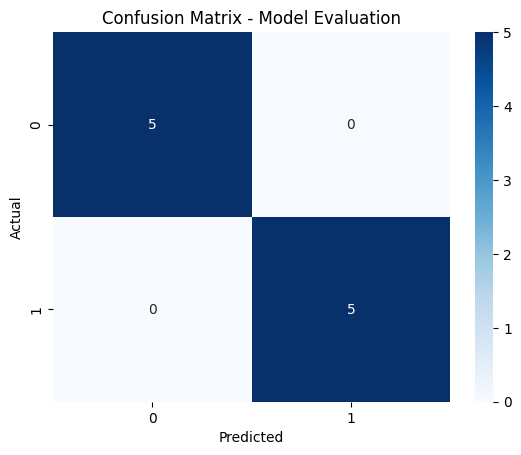

In [17]:
# confusion matrix visualization 
cm = confusion_matrix(df['churn'], y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Model Evaluation')
plt.show()